natasha: лемматизация корпуса новостей, мешок слов и косинусная близость

In [1]:
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsNERTagger,
    Doc,
)

segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

In [2]:
text = 'Сегодня в городе открыли новый парк для жителей.'
doc = Doc(text)
doc.segment(segmenter)
doc.tag_morph(morph_tagger)
doc.tokens[:8]

[DocToken(stop=7, text='Сегодня', pos='ADV', feats=<Pos>),
 DocToken(start=8, stop=9, text='в', pos='ADP'),
 DocToken(start=10, stop=16, text='городе', pos='NOUN', feats=<Inan,Loc,Masc,Sing>),
 DocToken(start=17, stop=24, text='открыли', pos='VERB', feats=<Perf,Ind,Plur,Past,Fin,Act>),
 DocToken(start=25, stop=30, text='новый', pos='ADJ', feats=<Inan,Acc,Pos,Masc,Sing>),
 DocToken(start=31, stop=35, text='парк', pos='NOUN', feats=<Inan,Acc,Masc,Sing>),
 DocToken(start=36, stop=39, text='для', pos='ADP'),
 DocToken(start=40, stop=47, text='жителей', pos='NOUN', feats=<Anim,Gen,Masc,Plur>)]

In [3]:
import csv

with open('news.csv', encoding='utf-8') as file:
    news = csv.DictReader(file)
    corpus = [Doc(line['text']) for line in news]
len(corpus)

12

In [4]:
for line in corpus:
    line.segment(segmenter)
    line.tag_morph(morph_tagger)
print(corpus[0])

Doc(text='В городе открыли новый парк, где жители смогут гу..., tokens=[...], sents=[...])


In [5]:
stop_morph = {'SCONJ', 'PUNCT', 'ADP', 'COMP', 'NPRO', 'PREP', 'CONJ',
              'PRED', 'PRCL', 'INTJ', 'CCONJ', 'PRON', 'ADV'}

def preprocessing(line):
    for token in line.tokens:
        token.lemmatize(morph_vocab)
    return [w.lemma for w in line.tokens if w.pos not in stop_morph]

corpus = list(map(preprocessing, corpus))
corpus[0]

['город',
 'открыть',
 'новый',
 'парк',
 'житель',
 'смочь',
 'гулять',
 'заниматься',
 'спорт']

In [6]:
corpus_uni = set()
for line in corpus:
    corpus_uni |= set(line)
len(corpus_uni)

87

In [7]:
import tqdm

basis = {elem: i for i, elem in enumerate(corpus_uni)}
dim = len(basis)
matrix = []
for line in tqdm.tqdm(corpus):
    vec = [0] * dim
    for word in line:
        vec[basis[word]] += 1
    matrix.append(vec)

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 466033.78it/s]

косинусная близость первого документа ко всем остальным

In [8]:
def cosin_near(vec1, vec2):
    num = 0
    norsum1 = 0
    norsum2 = 0
    for i in range(len(vec1)):
        num += vec1[i] * vec2[i]
        norsum1 += vec1[i] ** 2
        norsum2 += vec2[i] ** 2
    norsum1 **= 0.5
    norsum2 **= 0.5
    return num / (norsum2 * norsum1)

cos_max = [0, -1]
for i, vec in enumerate(matrix):
    if i == 0:
        continue
    cos = cosin_near(matrix[0], vec)
    if cos > cos_max[1]:
        cos_max = [i, cos]

print(*corpus[0])
print(*corpus[cos_max[0]])

город открыть новый парк житель смочь гулять заниматься спорт
кафе площадь предложить новый меню сезонный фрукт ягода


In [9]:
similarities = []
for i, vec in enumerate(matrix):
    if i == 0:
        continue
    similarities.append(cosin_near(matrix[0], vec))

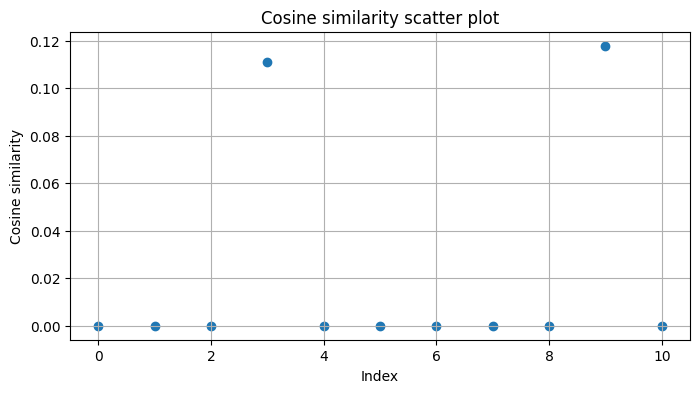

In [10]:
import numpy as np
import matplotlib.pyplot as plt

similarities = np.array(similarities)
x = np.arange(len(similarities))
plt.figure(figsize=(8, 4))
plt.scatter(x, similarities)
plt.xlabel('Index')
plt.ylabel('Cosine similarity')
plt.title('Cosine similarity scatter plot')
plt.grid(True)
plt.show()